# 🗑️ Tri des Déchets — Classification par Deep Learning
### Pipeline complet : ResNet18 Fine-tuné + Data Augmentation + WeightedRandomSampler
**6 catégories** : cardboard, glass, metal, paper, plastic, trash

---
## Versions
- **V1** : ResNet18 + Data Augmentation basique → 88.02%
- **V2** : + Class Weighting (CrossEntropyLoss) → 87% (plastic +5% mais global -1%)
- **V3** : + WeightedRandomSampler + Dropout réduit + patience=4 → objectif 90%+

## 📦 Cellule 1 — Imports & configuration globale

In [1]:
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision import datasets
from torch.utils.data import random_split, DataLoader, Subset, WeightedRandomSampler

import matplotlib.pyplot as plt
import numpy as np
import os
import time
import shutil
from pathlib import Path
from PIL import Image

# ─── SEED pour reproductibilité ───────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# ⚡ optimisation CPU
torch.set_num_threads(4)

# ─── GPU ou CPU ───────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
pin_memory = True if device.type == 'cuda' else False

# ─── CHEMIN DU DATASET ────────────────────────────────────────
DATASET_PATH = Path(r'C:\Users\DELL\Desktop\PCD\archive\garbage_classification')

# ─── HYPERPARAMÈTRES GLOBAUX ──────────────────────────────────
BATCH_SIZE    = 16   # 🔥 réduit pour CPU
NUM_CLASSES   = 6
LEARNING_RATE = 3e-4  # ⚡ convergence plus rapide
SAVE_PATH     = 'best_model_version chat.pth'
CLASSES = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

assert NUM_CLASSES == len(CLASSES), "Mismatch classes!"

## 🧹 Cellule 2 — Nettoyage des fichiers cachés Jupyter

In [2]:
print('Nettoyage des fichiers fantômes Jupyter...')
for root, dirs, files in os.walk(DATASET_PATH):
    for d in dirs:
        if d == '.ipynb_checkpoints':
            path_to_remove = os.path.join(root, d)
            shutil.rmtree(path_to_remove, ignore_errors=True)
            print(f'  🗑️ Supprimé : {path_to_remove}')
print('✅ Nettoyage terminé.')

Nettoyage des fichiers fantômes Jupyter...
✅ Nettoyage terminé.


## 🔄 Cellule 3 — Transforms (Data Augmentation + Normalisation ImageNet)

In [3]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Transform ENTRAÎNEMENT : augmentation enrichie
train_transform = transforms.Compose([
    transforms.Resize((160, 160)),  # ⚡ plus rapide CPU

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(15),  # ✔️ réduit (plus réaliste)

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),

    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# Transform VALIDATION/TEST : simple
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

print('✅ Transforms définis.')
print('  Train : Resize + Flip + Rotation + ColorJitter + Perspective + Normalize')
print('  Val   : Resize + Normalize')

✅ Transforms définis.
  Train : Resize + Flip + Rotation + ColorJitter + Perspective + Normalize
  Val   : Resize + Normalize


## 📂 Cellule 4 — Chargement du dataset & split Train/Val/Test + WeightedRandomSampler

In [4]:
# ─── Charger le dataset SANS transform ─────────────────────────
full_dataset = datasets.ImageFolder(root=str(DATASET_PATH))

print(f'Classes         : {full_dataset.classes}')
print(f'Total images    : {len(full_dataset)}')

# ─── Split 70 / 15 / 15 ───────────────────────────────────────
total      = len(full_dataset)
train_size = int(0.70 * total)
val_size   = int(0.15 * total)
test_size  = total - train_size - val_size

generator = torch.Generator().manual_seed(SEED)

train_indices, val_indices, test_indices = random_split(
    range(total),
    [train_size, val_size, test_size],
    generator=generator
)

# ─── Datasets avec transforms séparés ─────────────────────────
train_set = Subset(
    datasets.ImageFolder(str(DATASET_PATH), transform=train_transform),
    train_indices
)

val_set = Subset(
    datasets.ImageFolder(str(DATASET_PATH), transform=val_transform),
    val_indices
)

test_set = Subset(
    datasets.ImageFolder(str(DATASET_PATH), transform=val_transform),
    test_indices
)

# ─── Calcul des classes (train uniquement) ─────────────────────
labels = [full_dataset.targets[i] for i in train_indices]
labels_tensor = torch.tensor(labels)

class_counts = torch.bincount(labels_tensor)

print('\nImages par classe (train) :')
for cls, count in zip(CLASSES, class_counts):
    print(f'  {cls:12s} : {int(count)}')

# ─── Class weights (pour loss) ────────────────────────────────
class_weights = 1. / class_counts.float()
class_weights = class_weights / class_weights.sum()

# ─── Sample weights (pour sampler) ────────────────────────────
sample_weights = [1.0 / class_counts[label].item() for label in labels]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# ─── DataLoaders optimisés CPU ────────────────────────────────
train_loader = DataLoader(
    train_set,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=0,
    pin_memory=False
)

val_loader = DataLoader(
    val_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

test_loader = DataLoader(
    test_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

print(f'\nTrain : {len(train_set):4d} images  ({len(train_loader)} batches)')
print(f'Val   : {len(val_set):4d} images  ({len(val_loader)} batches)')
print(f'Test  : {len(test_set):4d} images  ({len(test_loader)} batches)')

print('\n✅ DataLoaders prêts (CPU optimisé + classes équilibrées)')

Classes         : ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Total images    : 7967

Images par classe (train) :
  cardboard    : 943
  glass        : 961
  metal        : 923
  paper        : 950
  plastic      : 945
  trash        : 854

Train : 5576 images  (349 batches)
Val   : 1195 images  (75 batches)
Test  : 1196 images  (75 batches)

✅ DataLoaders prêts (CPU optimisé + classes équilibrées)


## 👁️ Cellule 5 — Visualisation : exemples d'images par catégorie

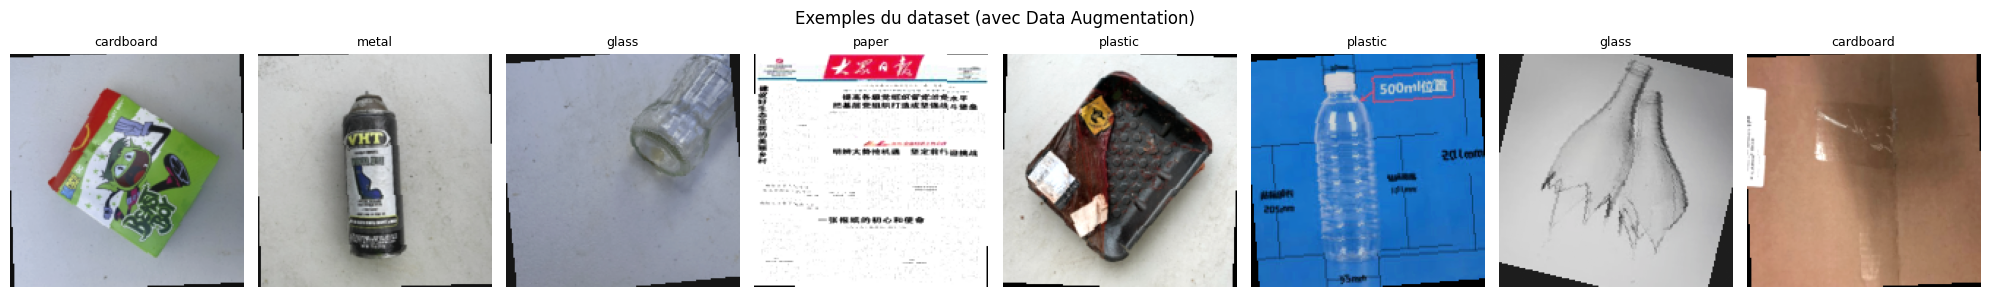

In [5]:
def imshow_batch(loader, classes, n=8):
    images, labels = next(iter(loader))
    mean = torch.tensor(IMAGENET_MEAN).view(3,1,1)
    std  = torch.tensor(IMAGENET_STD).view(3,1,1)
    images_show = images[:n] * std + mean
    images_show = images_show.clamp(0, 1)

    fig, axes = plt.subplots(1, n, figsize=(20, 3))
    for i in range(n):
        img = images_show[i].permute(1, 2, 0).numpy()
        axes[i].imshow(img)
        axes[i].set_title(classes[labels[i]], fontsize=9)
        axes[i].axis('off')
    plt.suptitle('Exemples du dataset (avec Data Augmentation)', fontsize=12)
    plt.tight_layout()
    plt.show()

imshow_batch(train_loader, CLASSES)

## 🏗️ Cellule 6 — Modèle ResNet18 avec Dropout réduit (V3)

In [6]:
# ─── 1. Charger ResNet18 pré-entraîné ─────────────────────────
model = models.resnet18(weights='IMAGENET1K_V1')

# ─── 2. Geler tout ───────────────────────────────────────────
for param in model.parameters():
    param.requires_grad = False

# ─── 3. Débloquer layer4 (🔥 très important)
for param in model.layer4.parameters():
    param.requires_grad = True

# ─── 4. Nouvelle tête optimisée ──────────────────────────────
model.fc = nn.Sequential(
    nn.Dropout(p=0.2),          # 🔥 réduit (évite underfitting)
    nn.Linear(512, 128),        # 🔥 plus simple = plus rapide CPU
    nn.ReLU(),
    nn.Dropout(p=0.2),
    nn.Linear(128, NUM_CLASSES)
)

# ─── 5. Débloquer la tête ────────────────────────────────────
for param in model.fc.parameters():
    param.requires_grad = True

model = model.to(device)

# ─── Stats ───────────────────────────────────────────────────
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params    = total_params - trainable_params

print('=' * 50)
print('Architecture : ResNet18 + Fine-tuning layer4 + FC optimisée')
print(f'Paramètres total      : {total_params:,}')
print(f'Paramètres entraîn.   : {trainable_params:,}')
print(f'Paramètres gelés      : {frozen_params:,}')
print('=' * 50)
print(f'Nouvelle tête fc : {model.fc}')

Architecture : ResNet18 + Fine-tuning layer4 + FC optimisée
Paramètres total      : 11,242,950
Paramètres entraîn.   : 8,460,166
Paramètres gelés      : 2,782,784
Nouvelle tête fc : Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=512, out_features=128, bias=True)
  (2): ReLU()
  (3): Dropout(p=0.2, inplace=False)
  (4): Linear(in_features=128, out_features=6, bias=True)
)


## ⚙️ Cellule 7 — Loss normale + Optimizer + Scheduler (patience=4)

In [7]:
# ─── Loss avec class weights ────────────────────────────────
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))

# ─── Optimizer amélioré ─────────────────────────────────────
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=2e-4,
    weight_decay=1e-4
)

# ─── Scheduler simple et efficace CPU ───────────────────────
scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=5,
    gamma=0.5
)

print('✅ Optimizer AdamW configuré.')
print(f'   LR initial    : 2e-4')
print(f'   Weight decay  : 1e-4')
print(f'   Scheduler     : StepLR (step=5, gamma=0.5)')
print(f'   Loss          : CrossEntropyLoss + class weights 🔥')

✅ Optimizer AdamW configuré.
   LR initial    : 2e-4
   Weight decay  : 1e-4
   Scheduler     : StepLR (step=5, gamma=0.5)
   Loss          : CrossEntropyLoss + class weights 🔥


## 🚀 Cellule 8 — Phase 1 : Entraînement de la tête (15 epochs)

In [8]:
# ─── Fonctions entraînement / évaluation ──────────────────────
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total   = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = outputs.max(1)
        total   += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return running_loss / len(loader), 100. * correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total   = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = outputs.max(1)
            total   += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    return running_loss / len(loader), 100. * correct / total


# ─── Entraînement (Phase 1 optimisée) ─────────────────────────
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

best_val_acc = 0.0
best_val_loss = float('inf')

PHASE1_EPOCHS = 15
patience = 5
counter = 0

print(f'=== PHASE 1 : Entraînement ({PHASE1_EPOCHS} epochs max) ===')
print(f'Device : {device}\n')

for epoch in range(PHASE1_EPOCHS):
    t0 = time.time()

    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss,   val_acc   = evaluate(model, val_loader, criterion, device)

    # ✅ Scheduler correct (StepLR)
    scheduler.step()

    # Historique
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    # ✅ Sauvegarde du meilleur modèle
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), SAVE_PATH)
        saved = '✅ sauvegardé'
    else:
        saved = ''

    # ✅ Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
    else:
        counter += 1

    duration = time.time() - t0

    print(f'Epoch [{epoch+1:2d}/{PHASE1_EPOCHS}] '
          f'| Train Loss: {train_loss:.4f} Acc: {train_acc:.1f}% '
          f'| Val Loss: {val_loss:.4f} Acc: {val_acc:.1f}% '
          f'| {duration:.1f}s {saved}')

    if counter >= patience:
        print("\n⛔ Early stopping activé (pas d'amélioration)")
        break

print(f'\n✅ Phase terminée. Meilleure val acc : {best_val_acc:.1f}%')

=== PHASE 1 : Entraînement (15 epochs max) ===
Device : cpu

Epoch [ 1/15] | Train Loss: 0.8142 Acc: 70.4% | Val Loss: 0.5499 Acc: 79.8% | 481.5s ✅ sauvegardé
Epoch [ 2/15] | Train Loss: 0.4913 Acc: 83.0% | Val Loss: 0.5389 Acc: 79.6% | 459.7s 
Epoch [ 3/15] | Train Loss: 0.4291 Acc: 85.3% | Val Loss: 0.5192 Acc: 81.8% | 241.5s ✅ sauvegardé
Epoch [ 4/15] | Train Loss: 0.3343 Acc: 88.6% | Val Loss: 0.4302 Acc: 85.4% | 265.2s ✅ sauvegardé
Epoch [ 5/15] | Train Loss: 0.2979 Acc: 90.0% | Val Loss: 0.4295 Acc: 85.6% | 267.4s ✅ sauvegardé
Epoch [ 6/15] | Train Loss: 0.2186 Acc: 92.8% | Val Loss: 0.3998 Acc: 86.4% | 256.8s ✅ sauvegardé
Epoch [ 7/15] | Train Loss: 0.1704 Acc: 94.3% | Val Loss: 0.4625 Acc: 85.5% | 250.2s 
Epoch [ 8/15] | Train Loss: 0.1487 Acc: 94.9% | Val Loss: 0.4019 Acc: 86.9% | 237.5s ✅ sauvegardé
Epoch [ 9/15] | Train Loss: 0.1496 Acc: 94.9% | Val Loss: 0.4119 Acc: 87.0% | 228.5s ✅ sauvegardé
Epoch [10/15] | Train Loss: 0.1259 Acc: 95.7% | Val Loss: 0.4510 Acc: 85.8% | 304

## 🔓 Cellule 9 — Phase 2 : Fine-tuning (dégel de layer4 + tête, 25 epochs)

In [9]:
# ─── Débloquer layer4 + FC ───────────────────────────────────
for name, param in model.named_parameters():
    if 'layer4' in name or 'fc' in name:
        param.requires_grad = True

# ─── Optimizer amélioré ──────────────────────────────────────
optimizer_ft = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=2e-5,   # 🔥 meilleur que 1e-5
    weight_decay=1e-4
)

# ─── Scheduler simple (CPU friendly) ─────────────────────────
PHASE2_EPOCHS = 25

scheduler_ft = optim.lr_scheduler.StepLR(
    optimizer_ft,
    step_size=7,
    gamma=0.5
)

# ─── Early stopping ─────────────────────────────────────────
patience = 5
counter = 0
best_val_loss = float('inf')

trainable_now = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'Paramètres entraînables maintenant : {trainable_now:,}')
print(f'LR fine-tuning : 2e-5')
print(f'\n=== PHASE 2 : Fine-tuning layer4 + FC ({PHASE2_EPOCHS} epochs max) ===\n')

for epoch in range(PHASE2_EPOCHS):
    t0 = time.time()

    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer_ft, criterion, device)
    val_loss,   val_acc   = evaluate(model, val_loader, criterion, device)

    scheduler_ft.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    # ✅ Sauvegarde
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), SAVE_PATH)
        saved = '✅ sauvegardé'
    else:
        saved = ''

    # ✅ Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
    else:
        counter += 1

    duration = time.time() - t0

    print(f'Epoch [{epoch+1:2d}/{PHASE2_EPOCHS}] '
          f'| Train Loss: {train_loss:.4f} Acc: {train_acc:.1f}% '
          f'| Val Loss: {val_loss:.4f} Acc: {val_acc:.1f}% '
          f'| {duration:.1f}s {saved}')

    if counter >= patience:
        print("\n⛔ Early stopping activé (Phase 2)")
        break

print(f'\n✅ Phase 2 terminée. Meilleure val acc : {best_val_acc:.1f}%')

Paramètres entraînables maintenant : 8,460,166
LR fine-tuning : 2e-5

=== PHASE 2 : Fine-tuning layer4 + FC (25 epochs max) ===

Epoch [ 1/25] | Train Loss: 0.0478 Acc: 98.5% | Val Loss: 0.3593 Acc: 89.5% | 271.4s 
Epoch [ 2/25] | Train Loss: 0.0478 Acc: 98.5% | Val Loss: 0.3939 Acc: 88.3% | 307.9s 
Epoch [ 3/25] | Train Loss: 0.0441 Acc: 98.5% | Val Loss: 0.3889 Acc: 88.9% | 284.3s 
Epoch [ 4/25] | Train Loss: 0.0365 Acc: 98.8% | Val Loss: 0.3854 Acc: 89.4% | 330.6s 
Epoch [ 5/25] | Train Loss: 0.0369 Acc: 98.9% | Val Loss: 0.3878 Acc: 89.0% | 241.9s 
Epoch [ 6/25] | Train Loss: 0.0376 Acc: 98.8% | Val Loss: 0.3939 Acc: 89.1% | 228.9s 

⛔ Early stopping activé (Phase 2)

✅ Phase 2 terminée. Meilleure val acc : 90.0%


## 📈 Cellule 10 — Courbes Loss & Accuracy

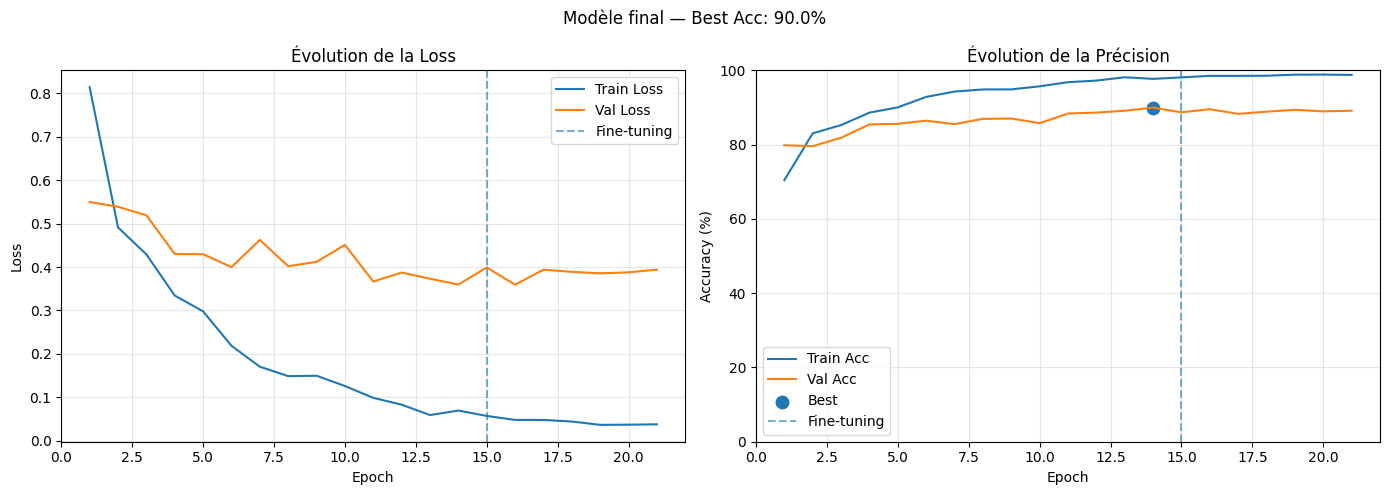

In [10]:
total_epochs = len(history['train_loss'])
x = range(1, total_epochs + 1)

best_epoch = np.argmax(history['val_acc']) + 1
best_acc = max(history['val_acc'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ─── LOSS ─────────────────────────────────────────────────────
ax1.plot(x, history['train_loss'], label='Train Loss')
ax1.plot(x, history['val_loss'],   label='Val Loss')
ax1.axvline(x=PHASE1_EPOCHS, linestyle='--', alpha=0.6, label='Fine-tuning')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Évolution de la Loss')
ax1.legend()
ax1.grid(alpha=0.3)

# ─── ACCURACY ─────────────────────────────────────────────────
ax2.plot(x, history['train_acc'], label='Train Acc')
ax2.plot(x, history['val_acc'],   label='Val Acc')

# 🔥 meilleur point
ax2.scatter(best_epoch, history['val_acc'][best_epoch-1], s=80, label='Best')

ax2.axvline(x=PHASE1_EPOCHS, linestyle='--', alpha=0.6, label='Fine-tuning')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_ylim(0, 100)
ax2.set_title('Évolution de la Précision')
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle(f'Modèle final — Best Acc: {best_acc:.1f}%')
plt.tight_layout()
plt.show()

## 🧪 Cellule 11 — Évaluation finale sur le Test Set

  RÉSULTATS FINAUX V3 (Test Set)
  Meilleure val acc : 89.96%
  Test Loss         : 0.3152
  Test Accuracy     : 90.55%

📊 Classification Report :
              precision    recall  f1-score   support

   cardboard       0.93      0.94      0.94       203
       glass       0.82      0.90      0.86       188
       metal       0.87      0.93      0.90       198
       paper       0.93      0.95      0.94       210
     plastic       0.93      0.77      0.84       213
       trash       0.95      0.96      0.95       184

    accuracy                           0.91      1196
   macro avg       0.91      0.91      0.91      1196
weighted avg       0.91      0.91      0.90      1196



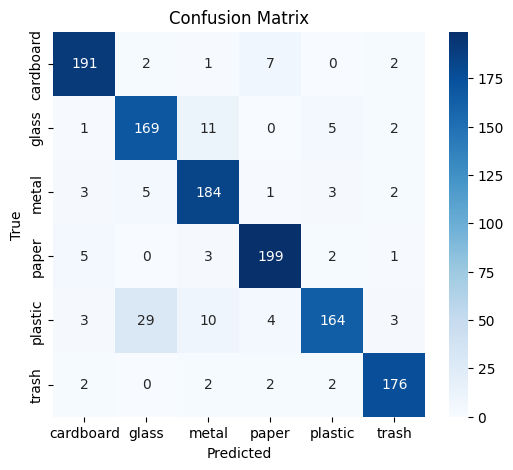


Comparaison des versions :
  V1 (baseline)           : 88.02%
  V2 (class weighting)    : 87.00%
  V3 (optimisé complet)   : 90.55%


In [11]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# ─── Charger le meilleur modèle ───────────────────────────────
model.load_state_dict(torch.load(SAVE_PATH, map_location=device))
model = model.to(device)
model.eval()

# ─── Test ─────────────────────────────────────────────────────
test_loss, test_acc = evaluate(model, test_loader, criterion, device)

print('=' * 45)
print(f'  RÉSULTATS FINAUX V3 (Test Set)')
print('=' * 45)
print(f'  Meilleure val acc : {best_val_acc:.2f}%')
print(f'  Test Loss         : {test_loss:.4f}')
print(f'  Test Accuracy     : {test_acc:.2f}%')
print('=' * 45)

# ─── Prédictions pour analyse ────────────────────────────────
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = outputs.max(1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# ─── Classification report ───────────────────────────────────
print('\n📊 Classification Report :')
print(classification_report(all_labels, all_preds, target_names=CLASSES))

# ─── Confusion Matrix ────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# ─── Comparaison versions ────────────────────────────────────
print('\nComparaison des versions :')
print(f'  V1 (baseline)           : 88.02%')
print(f'  V2 (class weighting)    : 87.00%')
print(f'  V3 (optimisé complet)   : {test_acc:.2f}%')

## 🗂️ Cellule 12 — Matrice de confusion par catégorie

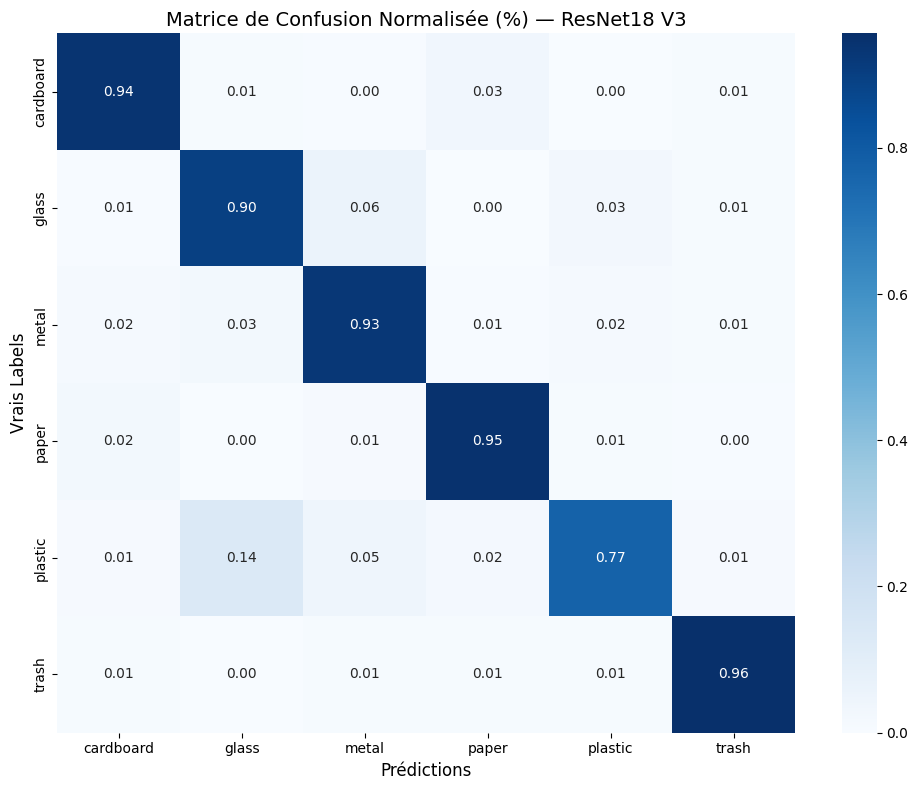


📊 Rapport de classification :
              precision    recall  f1-score   support

   cardboard       0.93      0.94      0.94       203
       glass       0.82      0.90      0.86       188
       metal       0.87      0.93      0.90       198
       paper       0.93      0.95      0.94       210
     plastic       0.93      0.77      0.84       213
       trash       0.95      0.96      0.95       184

    accuracy                           0.91      1196
   macro avg       0.91      0.91      0.91      1196
weighted avg       0.91      0.91      0.90      1196


🔥 F1-score global : 0.9048


In [12]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, f1_score

model.eval()
all_preds  = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# ─── Confusion Matrix brute ──────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)

# ─── Confusion Matrix normalisée (%) ─────────────────────────
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES)

plt.xlabel('Prédictions', fontsize=12)
plt.ylabel('Vrais Labels', fontsize=12)
plt.title('Matrice de Confusion Normalisée (%) — ResNet18 V3', fontsize=14)

plt.tight_layout()
plt.show()

# ─── Classification report ───────────────────────────────────
print('\n📊 Rapport de classification :')
print(classification_report(all_labels, all_preds, target_names=CLASSES))

# ─── F1-score global ─────────────────────────────────────────
f1 = f1_score(all_labels, all_preds, average='weighted')
print(f'\n🔥 F1-score global : {f1:.4f}')

## 💾 Cellule 13 — Sauvegarde finale du modèle

In [ ]:
from datetime import datetime

checkpoint = {
    # ─── Modèle ───────────────────────────────────────────────
    'model_state_dict' : model.state_dict(),
    
    # ─── Dataset ──────────────────────────────────────────────
    'classes'          : CLASSES,
    'num_classes'      : NUM_CLASSES,
    
    # ─── Performances ─────────────────────────────────────────
    'val_accuracy'     : best_val_acc,
    'test_accuracy'    : test_acc,
    
    # ─── Historique ───────────────────────────────────────────
    'history'          : history,
    
    # ─── Architecture ─────────────────────────────────────────
    'architecture'     : 'resnet18_v3_weighted_sampler',
    'version'          : 'V3',
    
    # ─── Hyperparamètres (🔥 important) ───────────────────────
    'batch_size'       : BATCH_SIZE,
    'learning_rate'    : LEARNING_RATE,
    'optimizer'        : 'AdamW',
    'scheduler'        : 'StepLR',
    
    # ─── Infos supplémentaires ────────────────────────────────
    'device'           : str(device),
    'date'             : datetime.now().strftime("%Y-%m-%d %H:%M:%S")
}

# ─── Sauvegarde ──────────────────────────────────────────────
FINAL_PATH = str(DATASET_PATH.parent / 'modele_resnet18_versionfinal.pth')
torch.save(checkpoint, FINAL_PATH)

print(f'✅ Modèle V3 sauvegardé : {FINAL_PATH}')
print(f'   Val Accuracy  : {best_val_acc:.2f}%')
print(f'   Test Accuracy : {test_acc:.2f}%')

✅ Modèle V3 sauvegardé : C:\Users\DELL\Desktop\PCD\archive\modele_resnet18_versionchat_final.pth
   Val Accuracy  : 89.96%
   Test Accuracy : 90.55%


In [7]:
!pip install opencv-python

## 📷 Cellule 14 — Prédiction avec la caméra en temps réel

In [8]:
def predict_image(image_path, model, transform, classes, device):
    img = Image.open(image_path).convert('RGB')
    tensor = transform(img).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        output = model(tensor)
        probas = torch.softmax(output, dim=1)[0]
    pred_idx   = probas.argmax().item()
    pred_class = classes[pred_idx]
    confidence = probas[pred_idx].item() * 100
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.imshow(img)
    ax1.set_title(f'Prédiction : {pred_class}\nConfiance : {confidence:.1f}%', fontsize=13)
    ax1.axis('off')
    colors = ['tomato' if i == pred_idx else 'steelblue' for i in range(len(classes))]
    ax2.barh(classes, probas.cpu().numpy() * 100, color=colors)
    ax2.set_xlabel('Probabilité (%)')
    ax2.set_title('Scores par catégorie')
    ax2.set_xlim(0, 100)
    plt.tight_layout()
    plt.show()
    return pred_class, confidence

print('✅ Fonction predict_image() prête.')
print('   Usage : predict_image(r"chemin/image.jpg", model, val_transform, CLASSES, device)')

✅ Fonction predict_image() prête.
   Usage : predict_image(r"chemin/image.jpg", model, val_transform, CLASSES, device)


In [11]:
model.load_state_dict(torch.load('best_model_version chat.pth', map_location=device))
model = model.to(device)
model.eval()
print("✅ Modèle V3 chargé !")

✅ Modèle V3 chargé !


In [22]:
import cv2
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from torch import nn
from PIL import Image
from collections import deque
import numpy as np

# ─── Catégories ───────────────────────────────────────────────
CLASSES = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

# ─── Charger le modèle ────────────────────────────────────────
resnet = models.resnet18(weights=None)
resnet.fc = nn.Sequential(
    nn.Dropout(p=0.2),
    nn.Linear(512, 128),
    nn.ReLU(),
    nn.Dropout(p=0.2),
    nn.Linear(128, 6)
)
checkpoint = torch.load(
    'best_model_version chat.pth',
    map_location='cpu',
    weights_only=False
)
resnet.load_state_dict(checkpoint)
resnet.eval()
print("Modèle chargé ✅")

# ─── Transform IDENTIQUE au train (160x160) ───────────────────
camera_transform = transforms.Compose([
    transforms.Resize((160, 160)),   # ✅ même taille qu'à l'entraînement
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# ─── Seuils abaissés pour le glass ────────────────────────────
SEUILS = {
    'cardboard' : 60.0,
    'glass'     : 55.0,  # ✅ abaissé (classe difficile)
    'metal'     : 65.0,
    'paper'     : 70.0,
    'plastic'   : 65.0,
    'trash'     : 55.0,
}

# ─── Lissage temporel ─────────────────────────────────────────
historique_probas = deque(maxlen=12)
votes             = deque(maxlen=10)

cap = cv2.VideoCapture(0)
print("Webcam ouverte — appuyez sur Q pour quitter")

while True:
    ret, frame = cap.read()
    if not ret:
        break

    h, w = frame.shape[:2]

    # ── Zone ROI 80% au centre ────────────────────────────────
    roi_size = int(min(h, w) * 0.80)
    cx, cy   = w // 2, h // 2
    x1 = cx - roi_size // 2
    y1 = cy - roi_size // 2
    x2 = cx + roi_size // 2
    y2 = cy + roi_size // 2

    roi       = frame[y1:y2, x1:x2]
    image_pil = Image.fromarray(cv2.cvtColor(roi, cv2.COLOR_BGR2RGB))

    # ── Prédiction simple et cohérente ────────────────────────
    with torch.no_grad():
        tenseur = camera_transform(image_pil).unsqueeze(0)
        outputs = resnet(tenseur)
        probas  = torch.softmax(outputs, dim=1)[0]

    # ── Lissage temporel ──────────────────────────────────────
    historique_probas.append(probas.numpy())
    probas_lissees = torch.tensor(np.mean(historique_probas, axis=0))
    top_proba, top_idx = torch.topk(probas_lissees, 3)

    cat1 = CLASSES[top_idx[0].item()]
    pct1 = top_proba[0].item() * 100

    # ── Système de votes pour confirmer ───────────────────────
    seuil_classe = SEUILS[cat1]
    if pct1 >= seuil_classe:
        votes.append(cat1)
    else:
        votes.append('inconnu')

    confirme = False
    if len(votes) == 10:
        compteur = {}
        for v in votes:
            compteur[v] = compteur.get(v, 0) + 1
        classe_maj = max(compteur, key=compteur.get)
        if classe_maj != 'inconnu' and compteur[classe_maj] >= 7:
            confirme = True
            cat1     = classe_maj

    # ── Couleur selon confiance ───────────────────────────────
    if confirme and pct1 >= seuil_classe:
        couleur_cadre = (0, 255, 0)
    elif pct1 > 50:
        couleur_cadre = (0, 165, 255)
    else:
        couleur_cadre = (0, 0, 255)

    # ── Assombrir tout sauf ROI ───────────────────────────────
    overlay = frame.copy()
    cv2.rectangle(overlay, (0, 0), (w, h), (0, 0, 0), -1)
    cv2.addWeighted(overlay, 0.4, frame, 0.6, 0, frame)
    frame[y1:y2, x1:x2] = roi

    # ── Cadre autour de la ROI ────────────────────────────────
    cv2.rectangle(frame, (x1, y1), (x2, y2), couleur_cadre, 3)

    # ── Coins décoratifs style scanner ────────────────────────
    coin = 30
    ep   = 4
    for (px, py, dx, dy) in [(x1,y1,1,1),(x2,y1,-1,1),
                               (x1,y2,1,-1),(x2,y2,-1,-1)]:
        cv2.line(frame, (px, py), (px + dx*coin, py), couleur_cadre, ep)
        cv2.line(frame, (px, py), (px, py + dy*coin), couleur_cadre, ep)

    # ── Message selon état ────────────────────────────────────
    if pct1 < 40:
        cv2.putText(frame, "Placez le dechet dans le cadre",
                    (x1, y1 - 15),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
    elif not confirme:
        cv2.putText(frame, "Analyse en cours...",
                    (x1, y1 - 15),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (200, 200, 200), 2)
    else:
        cv2.putText(frame, "CONFIRME",
                    (x1, y1 - 15),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    # ── Résultats en bas ──────────────────────────────────────
    cv2.rectangle(frame, (0, h-110), (w, h), (0, 0, 0), -1)

    if confirme and pct1 >= seuil_classe:
        cv2.putText(frame, f"{cat1.upper()}  {pct1:.1f}%",
                    (20, h - 70),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 255, 0), 2)
    else:
        cv2.putText(frame, f"{cat1.upper()}  {pct1:.1f}%",
                    (20, h - 70),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.2, couleur_cadre, 2)

    for i in range(1, 3):
        cat = CLASSES[top_idx[i].item()]
        pct = top_proba[i].item() * 100
        cv2.putText(frame, f"  {i+1}. {cat}: {pct:.1f}%",
                    (20, h - 45 + i*22),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (200, 200, 200), 1)

    cv2.imshow("Tri des dechets - Q pour quitter", frame)

    if cv2.waitKey(30) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()
print("Demo terminee")

Modèle chargé ✅
Webcam ouverte — appuyez sur Q pour quitter
Demo terminee
